# Assignment 3 - Dimensionality Reduction for AMZN

Notebook sử dụng toàn bộ dữ liệu AMZN giai đoạn 2010–2016. Phần đầu làm sạch dữ liệu; phần tiếp theo tạo 25 feature từ OHLCV để chuẩn bị cho RFE, RFECV và PCA.

Ở bước hiện tại, notebook **chưa** tạo target, chưa chia train/validation/test và chưa chạy thuật toán giảm chiều.

## 1. Khai báo thư viện và đọc dữ liệu

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path('../../dataset')
AMZN = ['AMZN']

# Giá split-adjusted tránh biến động giả do stock split.
prices_raw = pd.read_csv(
    DATA_DIR / 'prices-split-adjusted.csv', parse_dates=['date']
)
fund_raw = pd.read_csv(
    DATA_DIR / 'fundamentals.csv',
    index_col=0,
    parse_dates=['Period Ending']
)
# CIK là identifier nên đọc dạng chuỗi.
securities_raw = pd.read_csv(
    DATA_DIR / 'securities.csv', dtype={'CIK': 'string'}
)

pd.DataFrame({
    'dataset': ['prices', 'fundamentals', 'securities'],
    'rows': [len(prices_raw), len(fund_raw), len(securities_raw)],
    'columns': [prices_raw.shape[1], fund_raw.shape[1], securities_raw.shape[1]]
})

,dataset,rows,columns
0,prices,851264,7
1,fundamentals,1781,78
2,securities,505,8


In [42]:
prices_raw.head(3)

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0


## 2. Làm sạch dữ liệu giá

Mỗi observation là một phiên giao dịch của AMZN; khóa kỳ vọng là `(symbol, date)`. Kiểm tra được thực hiện trên toàn bộ lịch sử AMZN, không lọc năm 2016.

In [43]:
prices_clean = (
    prices_raw.loc[prices_raw['symbol'].isin(AMZN)]
    .copy()
    .sort_values(['symbol', 'date'])
    .reset_index(drop=True)
)

price_audit_before = pd.Series({
    'rows': len(prices_clean),
    'symbols': prices_clean['symbol'].nunique(),
    'missing_cells': int(prices_clean.isna().sum().sum()),
    'duplicate_rows': int(
        prices_clean.duplicated(['symbol', 'date'], keep=False).sum()
    ),
    'first_date': prices_clean['date'].min(),
    'last_date': prices_clean['date'].max()
}, name='value')

price_rule_checks = pd.DataFrame({
    'rule': [
        'open <= 0', 'close <= 0', 'low <= 0', 'high <= 0',
        'volume < 0', 'low > open', 'low > close',
        'high < open', 'high < close'
    ],
    'invalid_rows': [
        prices_clean['open'].le(0).sum(),
        prices_clean['close'].le(0).sum(),
        prices_clean['low'].le(0).sum(),
        prices_clean['high'].le(0).sum(),
        prices_clean['volume'].lt(0).sum(),
        prices_clean['low'].gt(prices_clean['open']).sum(),
        prices_clean['low'].gt(prices_clean['close']).sum(),
        prices_clean['high'].lt(prices_clean['open']).sum(),
        prices_clean['high'].lt(prices_clean['close']).sum()
    ]
})

display(price_audit_before.to_frame())
display(price_rule_checks)

,value
rows,1762
symbols,1
missing_cells,0
duplicate_rows,0
first_date,2010-01-04 00:00:00
last_date,2016-12-30 00:00:00


,rule,invalid_rows
0,open <= 0,0
1,close <= 0,0
2,low <= 0,0
3,high <= 0,0
4,volume < 0,0
5,low > open,0
6,low > close,0
7,high < open,0
8,high < close,0


### 2.1. Xử lý và xác nhận

Duplicate được loại theo khóa nếu có. OHLCV không hợp lệ làm notebook dừng để kiểm tra nguồn, không bị âm thầm sửa/xóa. Biến động giá lớn nhưng hợp lệ được giữ vì có thể là sự kiện thị trường thật.

In [44]:
prices_clean = (
    prices_clean
    .drop_duplicates(['symbol', 'date'], keep='first')
    .sort_values(['symbol', 'date'])
    .reset_index(drop=True)
)

assert prices_clean['symbol'].nunique() == len(AMZN)
assert set(prices_clean['symbol']) == set(AMZN)
assert prices_clean.notna().all().all()
assert not prices_clean.duplicated(['symbol', 'date']).any()
assert price_rule_checks['invalid_rows'].sum() == 0

prices_clean.groupby('symbol').agg(
    rows=('date', 'size'),
    first_date=('date', 'min'),
    last_date=('date', 'max')
)

,rows,first_date,last_date
symbol,,,
AMZN,1762,2010-01-04,2016-12-30


## 3. Làm sạch metadata doanh nghiệp

Chỉ giữ định danh và ngành có thể dùng sau này. `Date first added` không dùng nên missing của trường đó không cần impute.

In [45]:
metadata_columns = [
    'Ticker symbol', 'Security', 'GICS Sector', 'GICS Sub Industry'
]
metadata_clean = (
    securities_raw.loc[
        securities_raw['Ticker symbol'].isin(AMZN),
        metadata_columns
    ]
    .copy()
    .drop_duplicates('Ticker symbol', keep='first')
    .sort_values('Ticker symbol')
    .reset_index(drop=True)
)

assert set(metadata_clean['Ticker symbol']) == set(AMZN)
assert not metadata_clean['Ticker symbol'].duplicated().any()
assert metadata_clean.notna().all().all()
metadata_clean

,Ticker symbol,Security,GICS Sector,GICS Sub Industry
0,AMZN,Amazon.com Inc,Consumer Discretionary,Internet & Direct Marketing Retail


## 4. Làm sạch dữ liệu fundamentals

Khóa kỳ vọng là `(Ticker Symbol, Period Ending)`. Missing được xử lý theo ý nghĩa từng biến thay vì điền trung bình chung.

In [46]:
fund_clean = (
    fund_raw.loc[fund_raw['Ticker Symbol'].isin(AMZN)]
    .copy()
    .sort_values(['Ticker Symbol', 'Period Ending'])
    .reset_index(drop=True)
)

fund_duplicate_mask = fund_clean.duplicated(
    ['Ticker Symbol', 'Period Ending'], keep=False
)
missing_before = pd.DataFrame({
    'missing_count': fund_clean.isna().sum(),
    'missing_percent': fund_clean.isna().mean().mul(100)
})
missing_before = missing_before[missing_before['missing_count'] > 0]

print('Duplicate fundamental rows:', int(fund_duplicate_mask.sum()))
display(missing_before)

Duplicate fundamental rows: 0


,missing_count,missing_percent
For Year,1,25.0
Earnings Per Share,1,25.0
Estimated Shares Outstanding,1,25.0


### 4.1. Xử lý missing có thể xử lý

- `For Year`: lấy năm từ `Period Ending`.
- `Estimated Shares Outstanding`: forward-fill **trong từng ticker**.
- `Earnings Per Share`: nếu thiếu và số cổ phiếu hợp lệ, tính bằng lợi nhuận dành cho cổ đông phổ thông chia số cổ phiếu.
- Các cột `_was_missing` là audit metadata, không phải technical features.

In [47]:
fund_clean = fund_clean.drop_duplicates(
    ['Ticker Symbol', 'Period Ending'], keep='first'
).copy()

fund_clean['for_year_was_missing'] = fund_clean['For Year'].isna()
fund_clean['eps_was_missing'] = fund_clean['Earnings Per Share'].isna()
fund_clean['shares_was_missing'] = (
    fund_clean['Estimated Shares Outstanding'].isna()
)

fund_clean['For Year'] = fund_clean['For Year'].fillna(
    fund_clean['Period Ending'].dt.year
)
fund_clean['Estimated Shares Outstanding'] = (
    fund_clean.groupby('Ticker Symbol')['Estimated Shares Outstanding']
    .ffill()
)

eps_mask = (
    fund_clean['Earnings Per Share'].isna()
    & fund_clean['Estimated Shares Outstanding'].gt(0)
    & fund_clean['Net Income Applicable to Common Shareholders'].notna()
)
fund_clean.loc[eps_mask, 'Earnings Per Share'] = (
    fund_clean.loc[eps_mask, 'Net Income Applicable to Common Shareholders']
    / fund_clean.loc[eps_mask, 'Estimated Shares Outstanding']
)

assert not fund_clean.duplicated(['Ticker Symbol', 'Period Ending']).any()

### 4.2. Kiểm tra kết quả xử lý missing của AMZN

Ba giá trị từng thiếu trong báo cáo AMZN mới nhất được xử lý và vẫn có cột cờ để truy vết. Bảng `missing_after` phải rỗng nếu không còn missing.

In [48]:
imputation_audit_columns = [
    'Ticker Symbol', 'Period Ending', 'For Year',
    'Estimated Shares Outstanding', 'Earnings Per Share',
    'for_year_was_missing', 'shares_was_missing', 'eps_was_missing'
]

amzn_imputation_audit = fund_clean.loc[
    fund_clean[
        ['for_year_was_missing', 'shares_was_missing', 'eps_was_missing']
    ].any(axis=1),
    imputation_audit_columns
]

missing_after = pd.DataFrame({
    'missing_count': fund_clean.isna().sum(),
    'missing_percent': fund_clean.isna().mean().mul(100)
})
missing_after = missing_after[missing_after['missing_count'] > 0]

display(amzn_imputation_audit)
display(missing_after)

,Ticker Symbol,Period Ending,For Year,Estimated Shares Outstanding,Earnings Per Share,for_year_was_missing,shares_was_missing,eps_was_missing
3,AMZN,2016-12-31,2016.0,465625000.0,5.092081,True,True,True


,missing_count,missing_percent


## 5. Tổng kết cleaning

Đầu ra của phần cleaning gồm `prices_clean`, `metadata_clean` và `fund_clean`. Phần tiếp theo chỉ sử dụng `prices_clean` để tạo feature cho dữ liệu ngày của AMZN.

In [49]:
cleaning_summary = pd.DataFrame({
    'dataset': ['prices_clean', 'metadata_clean', 'fund_clean'],
    'rows': [len(prices_clean), len(metadata_clean), len(fund_clean)],
    'columns': [
        prices_clean.shape[1], metadata_clean.shape[1], fund_clean.shape[1]
    ],
    'duplicate_keys': [
        prices_clean.duplicated(['symbol', 'date']).sum(),
        metadata_clean.duplicated(['Ticker symbol']).sum(),
        fund_clean.duplicated(['Ticker Symbol', 'Period Ending']).sum()
    ],
    'remaining_missing_cells': [
        prices_clean.isna().sum().sum(),
        metadata_clean.isna().sum().sum(),
        fund_clean.isna().sum().sum()
    ]
})
cleaning_summary

,dataset,rows,columns,duplicate_keys,remaining_missing_cells
0,prices_clean,1762,7,0,0
1,metadata_clean,1,4,0,0
2,fund_clean,4,81,0,0


## 6. Feature engineering

Mỗi dòng vẫn đại diện cho một phiên AMZN. Feature tại ngày (t) chỉ sử dụng dữ liệu có sẵn đến hết ngày (t).

Các horizon được chọn:

- 1 phiên: phản ứng mới nhất.
- 5 phiên: khoảng một tuần giao dịch.
- 10 phiên: khoảng hai tuần.
- 20 phiên: khoảng một tháng.
- 60 phiên: khoảng một quý.

Moving average và volatility có thể chứa observation ngày (t), vì bài toán giả định dự đoán được thực hiện sau khi phiên (t) đóng cửa. Riêng relative volume so sánh volume hiện tại với **các phiên trước**, nên baseline dùng `shift(1)`.

In [50]:
RETURN_WINDOWS = [1, 5, 10, 20, 60]
ROLLING_WINDOWS = [5, 10, 20, 60]

FEATURE_COLUMNS = [
    'return_1',
    'return_5',
    'return_10',
    'return_20',
    'return_60',

    'close_to_ma_5',
    'close_to_ma_10',
    'close_to_ma_20',
    'close_to_ma_60',
    'ma_5_to_ma_20',
    'ma_20_to_ma_60',

    'volatility_5',
    'volatility_10',
    'volatility_20',
    'volatility_60',

    'log_volume',
    'log_volume_change_1',
    'relative_volume_5',
    'relative_volume_10',
    'relative_volume_20',
    'relative_volume_60',

    'intraday_range',
    'candle_body',
    'overnight_gap',
    'close_position'
]

assert len(FEATURE_COLUMNS) == 25
FEATURE_COLUMNS

['return_1',
 'return_5',
 'return_10',
 'return_20',
 'return_60',
 'close_to_ma_5',
 'close_to_ma_10',
 'close_to_ma_20',
 'close_to_ma_60',
 'ma_5_to_ma_20',
 'ma_20_to_ma_60',
 'volatility_5',
 'volatility_10',
 'volatility_20',
 'volatility_60',
 'log_volume',
 'log_volume_change_1',
 'relative_volume_5',
 'relative_volume_10',
 'relative_volume_20',
 'relative_volume_60',
 'intraday_range',
 'candle_body',
 'overnight_gap',
 'close_position']

### 6.1. Return và trend

- `return_h`: mức thay đổi của close so với đúng (h) phiên trước.
- `close_to_ma_h`: vị trí close hiện tại so với moving average (h) phiên.
- `ma_5_to_ma_20` và `ma_20_to_ma_60`: so sánh xu hướng ngắn, trung và dài hạn.

Các tỷ lệ được trừ 1 để giá trị 0 mang nghĩa hai mức bằng nhau.

In [51]:
feature_data = prices_clean.copy()

close = feature_data['close']

# Cumulative returns over different horizons.
for window in RETURN_WINDOWS:
    feature_data[f'return_{window}'] = close.pct_change(window)

# Moving averages include the current close because it is known at prediction time.
moving_averages = {}
for window in ROLLING_WINDOWS:
    moving_averages[window] = close.rolling(
        window=window,
        min_periods=window
    ).mean()
    feature_data[f'close_to_ma_{window}'] = (
        close / moving_averages[window] - 1
    )

feature_data['ma_5_to_ma_20'] = (
    moving_averages[5] / moving_averages[20] - 1
)
feature_data['ma_20_to_ma_60'] = (
    moving_averages[20] / moving_averages[60] - 1
)

### 6.2. Volatility và volume

- `volatility_h`: standard deviation của daily return trong (h) phiên gần nhất.
- `log_volume`: nén phân phối volume lệch phải.
- `log_volume_change_1`: thay đổi log-volume so với phiên trước.
- `relative_volume_h`: volume hiện tại chia cho volume trung bình của (h) phiên **trước đó**.

In [52]:
daily_return = close.pct_change()

for window in ROLLING_WINDOWS:
    feature_data[f'volatility_{window}'] = daily_return.rolling(
        window=window,
        min_periods=window
    ).std()

feature_data['log_volume'] = np.log1p(feature_data['volume'])
feature_data['log_volume_change_1'] = feature_data['log_volume'].diff()

for window in ROLLING_WINDOWS:
    prior_volume_mean = (
        feature_data['volume']
        .shift(1)
        .rolling(window=window, min_periods=window)
        .mean()
    )
    feature_data[f'relative_volume_{window}'] = (
        feature_data['volume'] / prior_volume_mean
    )

### 6.3. Biến động trong phiên

- `intraday_range`: biên độ high–low so với open.
- `candle_body`: thay đổi từ open đến close.
- `overnight_gap`: chênh lệch open hiện tại với close phiên trước.
- `close_position`: vị trí close trong khoảng low–high; gần 0 là gần đáy, gần 1 là gần đỉnh.

In [53]:
feature_data['intraday_range'] = (
    (feature_data['high'] - feature_data['low'])
    / feature_data['open']
)
feature_data['candle_body'] = (
    (feature_data['close'] - feature_data['open'])
    / feature_data['open']
)
feature_data['overnight_gap'] = (
    feature_data['open'] / feature_data['close'].shift(1) - 1
)

daily_range = feature_data['high'] - feature_data['low']
feature_data['close_position'] = np.where(
    daily_range.gt(0),
    (feature_data['close'] - feature_data['low']) / daily_range,
    np.nan
)

### 6.4. Kiểm tra feature

Các NaN đầu chuỗi là **warm-up NaN**: ví dụ, feature 60 phiên chưa thể tính khi chưa có đủ lịch sử. Đây không phải lỗi dữ liệu và không được điền bằng 0.

`features_ready` loại các dòng chưa đủ toàn bộ 25 feature. Việc tạo target và bỏ dòng target cuối sẽ được thực hiện ở bước sau.

In [54]:
feature_missing = (
    feature_data[FEATURE_COLUMNS]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)

finite_values = np.isfinite(
    feature_data[FEATURE_COLUMNS].dropna().to_numpy()
).all()
assert finite_values, 'Feature matrix contains infinity.'
assert set(FEATURE_COLUMNS).issubset(feature_data.columns)

features_ready = (
    feature_data
    .dropna(subset=FEATURE_COLUMNS)
    .reset_index(drop=True)
)

feature_summary = pd.Series({
    'original_rows': len(feature_data),
    'feature_count': len(FEATURE_COLUMNS),
    'warmup_rows_removed': len(feature_data) - len(features_ready),
    'ready_rows': len(features_ready),
    'first_ready_date': features_ready['date'].min(),
    'last_ready_date': features_ready['date'].max(),
    'infinite_values': int(
        np.isinf(features_ready[FEATURE_COLUMNS].to_numpy()).sum()
    )
}, name='value')

display(feature_missing)
display(feature_summary.to_frame())
display(features_ready[['date', *FEATURE_COLUMNS]].head())

,missing_count
return_1,1
return_5,5
return_10,10
return_20,20
return_60,60
close_to_ma_5,4
close_to_ma_10,9
close_to_ma_20,19
close_to_ma_60,59
ma_5_to_ma_20,19


,value
original_rows,1762
feature_count,25
warmup_rows_removed,60
ready_rows,1702
first_ready_date,2010-03-31 00:00:00
last_ready_date,2016-12-30 00:00:00
infinite_values,0


,date,return_1,return_5,return_10,return_20,return_60,close_to_ma_5,close_to_ma_10,close_to_ma_20,close_to_ma_60,...,log_volume,log_volume_change_1,relative_volume_5,relative_volume_10,relative_volume_20,relative_volume_60,intraday_range,candle_body,overnight_gap,close_position
0,2010-03-31,-0.005931,0.060372,0.033729,0.078481,0.013966,0.002348,0.022257,0.030638,0.080372,...,15.341698,-0.297184,0.600737,0.695239,0.718574,0.464356,0.017059,-0.001691,-0.004247,0.556036
1,2010-04-01,-0.029167,-0.021673,-0.007156,0.025519,-0.021382,-0.022674,-0.006849,-0.000667,0.049262,...,15.988647,0.646950,1.150109,1.322870,1.392271,0.891282,0.039249,-0.029381,0.000221,0.118200
2,2010-04-05,-0.002428,-0.026433,0.008746,0.020014,-0.005747,-0.019858,-0.010110,-0.004067,0.046820,...,15.576209,-0.412438,0.945105,0.828807,0.912505,0.590125,0.022281,-0.010237,0.007890,0.239866
3,2010-04-06,0.030953,0.003256,0.039013,0.041888,0.042769,0.009818,0.016634,0.024645,0.078426,...,15.888720,0.312511,1.324057,1.185008,1.256652,0.808476,0.036729,0.032996,-0.001977,0.908713
4,2010-04-07,-0.005090,-0.012520,0.043401,0.046965,0.010111,0.007244,0.007222,0.017104,0.072745,...,15.598129,-0.290592,0.891474,0.853518,0.922655,0.607768,0.016328,-0.008017,0.002951,0.454952


### 6.5. Tạo Label target

Target là giá đóng phiên ngày mai có tăng so với giá đóng phiên ngày hnay hay k.

`1` sẽ là có 

`0` là không

In [55]:
feature_data['next_close'] = feature_data['close'].shift(-1)

feature_data['target_up'] = (
    feature_data['next_close']
    .gt(feature_data['close'])
    .where(feature_data['next_close'].notna())
    .astype('Int64')
)

model_data = (
    feature_data
    .dropna(subset=FEATURE_COLUMNS + ['target_up'])
    .copy()
)

model_data['target_up'] = model_data['target_up'].astype(int)

### 6.6. Kiểm tra mức cân bằng của target

Bảng dưới đây báo cáo số observation và tỷ lệ phần trăm của từng lớp trong `model_data`.

- `target_up = 0`: close phiên tiếp theo không tăng.
- `target_up = 1`: close phiên tiếp theo tăng.

Ngoài tỷ lệ phần trăm, `majority_to_minority_ratio` so sánh số mẫu của lớp lớn với lớp nhỏ. Giá trị càng gần 1 thì target càng cân bằng.

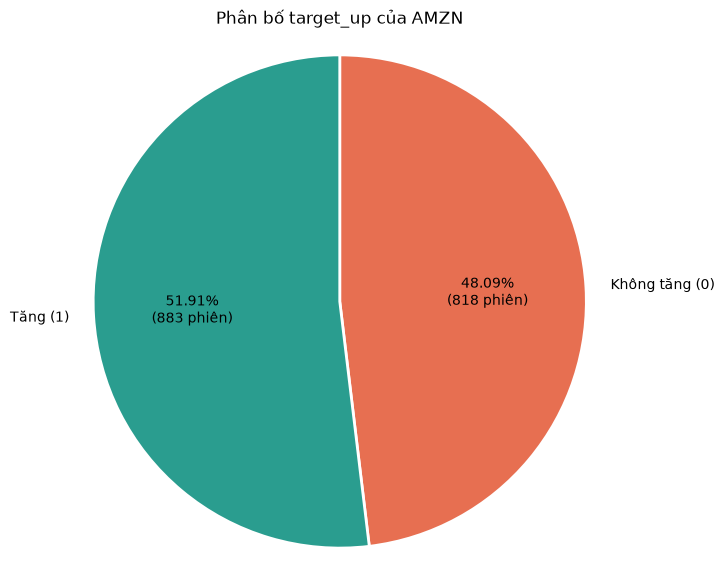

In [57]:
import matplotlib.pyplot as plt

target_counts = (
    model_data['target_up']
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

labels = [
    'Không tăng (0)',
    'Tăng (1)'
]

colors = ['#E76F51', '#2A9D8F']

def show_percentage_and_count(pct):
    count = round(pct / 100 * target_counts.sum())
    return f'{pct:.2f}%\n({count} phiên)'

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    target_counts.values,
    labels=labels,
    colors=colors,
    autopct=show_percentage_and_count,
    startangle=90,
    counterclock=False,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

ax.set_title('Phân bố target_up của AMZN')
ax.axis('equal')

plt.show()

### 7. RFECV và PCA

